# Churn Prediction — TabPFN & TabICL
Standard binary classification: predict P(churn) for each test member.
**Outreach is excluded as a feature** — it is a treatment variable, not a predictor of future churn.
Output: `predictions_churn_<model>.csv` with columns member_id, churn_score, rank (ranked descending).


In [1]:
import sys, warnings
sys.path.insert(0, '../Shay_Assignment_Uplift')
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
from tabpfn import TabPFNClassifier
from tabicl import TabICLClassifier
from feature_engineering import FEATURE_COLS
sns.set_style('whitegrid')
np.random.seed(42)
print("FEATURE_COLS:", FEATURE_COLS)


FEATURE_COLS: ['tenure_days', 'total_visits', 'wellco_visits', 'health_content_ratio', 'days_since_wellco', 'unique_wellco_domains', 'app_sessions', 'days_since_app', 'app_sessions_last7d', 'icd_E11_9', 'icd_I10', 'icd_Z71_3', 'unexpected_icd_count', 'expected_icd_count']


In [2]:
# Load pre-built features (from uplift pipeline)
train = pd.read_parquet('../Shay_Assignment_Uplift/train_features.parquet')
test  = pd.read_parquet('../Shay_Assignment_Uplift/test_features.parquet')

X_train = train[FEATURE_COLS].values.astype(float)
Y_train = train['churn'].values
X_test  = test[FEATURE_COLS].values.astype(float)

print(f"Train: {X_train.shape}, churn rate: {Y_train.mean():.4f}")
print(f"Test:  {X_test.shape}")
print(f"Note: outreach column excluded — not used as a feature")


Train: (10000, 14), churn rate: 0.2021
Test:  (10000, 14)
Note: outreach column excluded — not used as a feature


In [3]:
# Cross-validated AUC on train (5-fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_tabpfn = np.zeros(len(X_train))
oof_tabicl = np.zeros(len(X_train))

print("5-fold CV — TabPFN:")
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, Y_train)):
    m = TabPFNClassifier(n_estimators=8, random_state=42)
    m.fit(X_train[tr_idx], Y_train[tr_idx])
    oof_tabpfn[val_idx] = m.predict_proba(X_train[val_idx])[:, 1]
    print(f"  Fold {fold+1}: AUC={roc_auc_score(Y_train[val_idx], oof_tabpfn[val_idx]):.4f}")

print(f"  OOF AUC: {roc_auc_score(Y_train, oof_tabpfn):.4f}")
print(f"  Brier:   {brier_score_loss(Y_train, oof_tabpfn):.4f}")


5-fold CV — TabPFN:


  Fold 1: AUC=0.6614


  Fold 2: AUC=0.6549


  Fold 3: AUC=0.6816


  Fold 4: AUC=0.7004


  Fold 5: AUC=0.6631
  OOF AUC: 0.6715
  Brier:   0.1517


In [4]:
print("5-fold CV — TabICL:")
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, Y_train)):
    m = TabICLClassifier(random_state=42)
    m.fit(X_train[tr_idx], Y_train[tr_idx])
    oof_tabicl[val_idx] = m.predict_proba(X_train[val_idx])[:, 1]
    print(f"  Fold {fold+1}: AUC={roc_auc_score(Y_train[val_idx], oof_tabicl[val_idx]):.4f}")

print(f"  OOF AUC: {roc_auc_score(Y_train, oof_tabicl):.4f}")
print(f"  Brier:   {brier_score_loss(Y_train, oof_tabicl):.4f}")


5-fold CV — TabICL:


  Fold 1: AUC=0.6552


  Fold 2: AUC=0.6526


  Fold 3: AUC=0.6787


  Fold 4: AUC=0.6984


  Fold 5: AUC=0.6607
  OOF AUC: 0.6684
  Brier:   0.1521


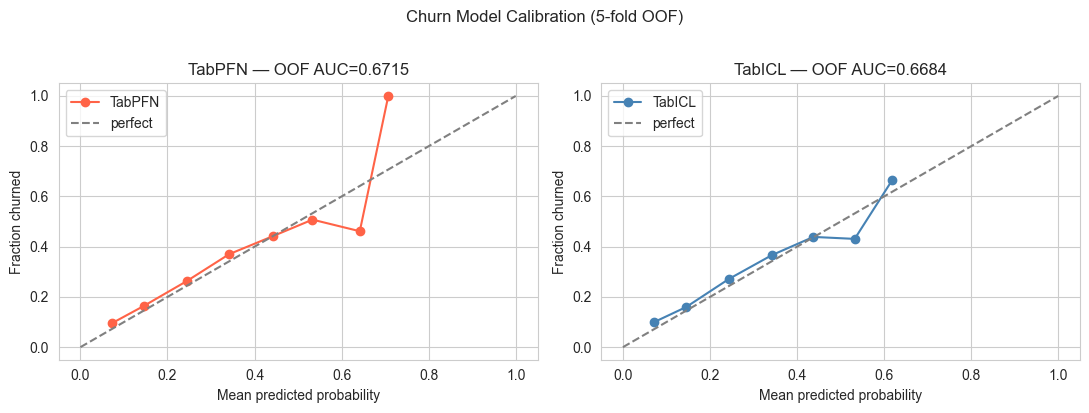

In [5]:
# OOF calibration plots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, oof, name, color in [
    (axes[0], oof_tabpfn, 'TabPFN', 'tomato'),
    (axes[1], oof_tabicl, 'TabICL', 'steelblue'),
]:
    pt, pp = calibration_curve(Y_train, oof, n_bins=10)
    ax.plot(pp, pt, 'o-', color=color, label=name)
    ax.plot([0,1],[0,1],'--', color='gray', label='perfect')
    auc = roc_auc_score(Y_train, oof)
    ax.set_title(f'{name} — OOF AUC={auc:.4f}')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction churned')
    ax.legend()
plt.suptitle('Churn Model Calibration (5-fold OOF)', y=1.02)
plt.tight_layout()
plt.savefig('churn_calibration.png', bbox_inches='tight')
plt.show()


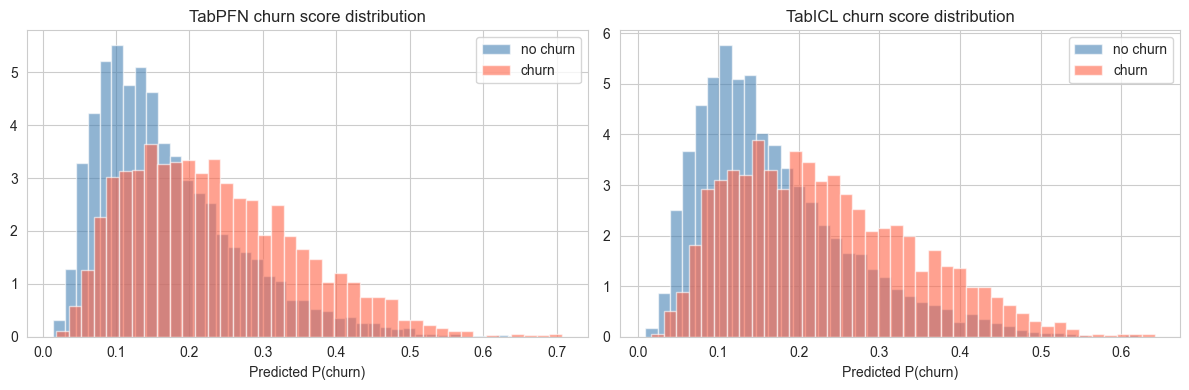

In [6]:
# Churn score distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, oof, name, color in [
    (axes[0], oof_tabpfn, 'TabPFN', 'tomato'),
    (axes[1], oof_tabicl, 'TabICL', 'steelblue'),
]:
    ax.hist(oof[Y_train==0], bins=40, alpha=0.6, label='no churn', color='steelblue', density=True)
    ax.hist(oof[Y_train==1], bins=40, alpha=0.6, label='churn',    color='tomato',    density=True)
    ax.set_title(f'{name} churn score distribution')
    ax.set_xlabel('Predicted P(churn)')
    ax.legend()
plt.tight_layout()
plt.savefig('churn_score_distribution.png', bbox_inches='tight')
plt.show()


In [7]:
# Fit final models on full training set and predict test
print("Fitting final models on full train...")

m_tabpfn = TabPFNClassifier(n_estimators=8, random_state=42)
m_tabpfn.fit(X_train, Y_train)
test_tabpfn = m_tabpfn.predict_proba(X_test)[:, 1]

m_tabicl = TabICLClassifier(random_state=42)
m_tabicl.fit(X_train, Y_train)
test_tabicl = m_tabicl.predict_proba(X_test)[:, 1]

test_ensemble = (test_tabpfn + test_tabicl) / 2

print(f"Test churn score — TabPFN:  mean={test_tabpfn.mean():.4f}, range=[{test_tabpfn.min():.4f}, {test_tabpfn.max():.4f}]")
print(f"Test churn score — TabICL:  mean={test_tabicl.mean():.4f}, range=[{test_tabicl.min():.4f}, {test_tabicl.max():.4f}]")
print(f"Test churn score — Ensemble: mean={test_ensemble.mean():.4f}, range=[{test_ensemble.min():.4f}, {test_ensemble.max():.4f}]")


Fitting final models on full train...


Test churn score — TabPFN:  mean=0.1828, range=[0.0165, 0.6730]
Test churn score — TabICL:  mean=0.1821, range=[0.0132, 0.6452]
Test churn score — Ensemble: mean=0.1825, range=[0.0149, 0.6591]


In [8]:
# Save prediction files — all 10k test members, ranked by churn_score descending
for scores, suffix in [
    (test_tabpfn,  'tabpfn'),
    (test_tabicl,  'tabicl'),
    (test_ensemble,'ensemble'),
]:
    df_out = test[['member_id']].copy()
    df_out['churn_score'] = scores
    df_out = df_out.sort_values('churn_score', ascending=False).reset_index(drop=True)
    df_out['rank'] = range(1, len(df_out) + 1)
    fname = f'predictions_churn_{suffix}.csv'
    df_out.to_csv(fname, index=False)
    print(f"{fname}: {len(df_out):,} members, score range [{df_out['churn_score'].min():.4f}, {df_out['churn_score'].max():.4f}]")


predictions_churn_tabpfn.csv: 10,000 members, score range [0.0165, 0.6730]
predictions_churn_tabicl.csv: 10,000 members, score range [0.0132, 0.6452]
predictions_churn_ensemble.csv: 10,000 members, score range [0.0149, 0.6591]


In [9]:
# Top-risk members profile
test_copy = test.copy()
test_copy['churn_score'] = test_ensemble
test_copy['risk_group'] = pd.qcut(test_copy['churn_score'], 4,
                                   labels=['Low','Med-Low','Med-High','High'])

from feature_engineering import FEATURE_COLS
print("Mean features by risk quartile:")
print(test_copy.groupby('risk_group', observed=True)[FEATURE_COLS[:6]].mean().round(2))


Mean features by risk quartile:
            tenure_days  total_visits  wellco_visits  health_content_ratio  \
risk_group                                                                   
Low              407.43         27.12          14.26                  0.51   
Med-Low          332.36         25.85          10.99                  0.40   
Med-High         276.92         25.44           8.99                  0.32   
High             198.25         26.27           6.63                  0.23   

            days_since_wellco  unique_wellco_domains  
risk_group                                            
Low                      1.18                   3.68  
Med-Low                  3.15                   3.40  
Med-High                 4.11                   3.17  
High                     6.20                   2.79  


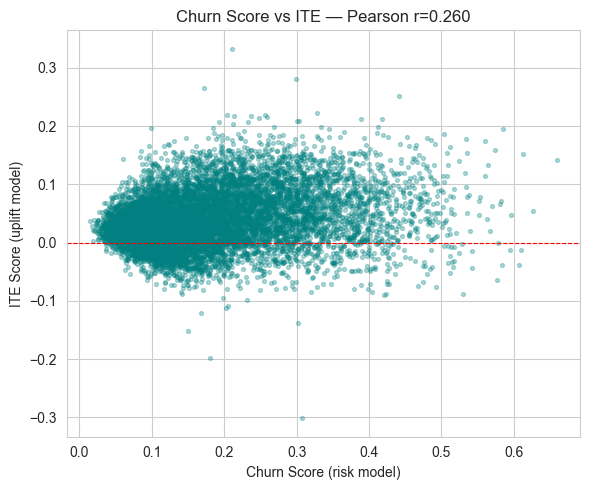

Pearson correlation (churn score vs ITE): 0.2599
Low correlation = uplift model targets different members than churn model


In [10]:
# OOF correlation: churn score vs ITE (uplift)
try:
    uplift = pd.read_parquet('../Shay_Assignment_Uplift/test_predictions_v2.parquet')
    comparison = test[['member_id']].copy()
    comparison['churn_score'] = test_ensemble
    comparison = comparison.merge(uplift[['member_id','ite_v2_ensemble']], on='member_id')
    corr = comparison['churn_score'].corr(comparison['ite_v2_ensemble'])

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(comparison['churn_score'], comparison['ite_v2_ensemble'],
               alpha=0.3, s=8, color='teal')
    ax.set_xlabel('Churn Score (risk model)')
    ax.set_ylabel('ITE Score (uplift model)')
    ax.set_title(f'Churn Score vs ITE — Pearson r={corr:.3f}')
    ax.axhline(0, color='red', ls='--', lw=0.8)
    plt.tight_layout()
    plt.savefig('churn_vs_ite.png', bbox_inches='tight')
    plt.show()
    print(f"Pearson correlation (churn score vs ITE): {corr:.4f}")
    print("Low correlation = uplift model targets different members than churn model")
except Exception as e:
    print(f"Could not load uplift predictions: {e}")
